In [5]:
import pandas as pd


results = pd.read_csv("archive/results.csv")
qualifying = pd.read_csv("archive/qualifying.csv")
races = pd.read_csv("archive/races.csv")
circuits = pd.read_csv("archive/circuits.csv")
status = pd.read_csv('archive/status.csv')

In [6]:
# Juntamos los archivos para tener nuestro dataset con todas las columnas que necesitamos


df = results.merge(qualifying, on=['raceId', 'driverId'], how='inner')
df = df.merge(races[['raceId', 'circuitId', 'year']], on='raceId', how='left')
df = df.merge(circuits[['circuitId', 'name', 'location']], on='circuitId', how='left')
df = df.merge(status, on='statusId', how='left')




df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10494 entries, 0 to 10493
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         10494 non-null  int64  
 1   raceId           10494 non-null  int64  
 2   driverId         10494 non-null  int64  
 3   constructorId_x  10494 non-null  int64  
 4   number_x         10494 non-null  object 
 5   grid             10494 non-null  int64  
 6   position_x       10494 non-null  object 
 7   positionText     10494 non-null  object 
 8   positionOrder    10494 non-null  int64  
 9   points           10494 non-null  float64
 10  laps             10494 non-null  int64  
 11  time             10494 non-null  object 
 12  milliseconds     10494 non-null  object 
 13  fastestLap       10494 non-null  object 
 14  rank             10494 non-null  object 
 15  fastestLapTime   10494 non-null  object 
 16  fastestLapSpeed  10494 non-null  object 
 17  statusId    

In [7]:
#hacemos un dataset con las variables que me importan para mi analisis (no incluimos variables muy especificas que no vamos a usar)
df_clean = df[[
   'raceId',
   'driverId',
   'grid',
   'positionOrder',
   'circuitId',
   'name',
   'year',
   'status'
]]


df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10494 entries, 0 to 10493
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   raceId         10494 non-null  int64 
 1   driverId       10494 non-null  int64 
 2   grid           10494 non-null  int64 
 3   positionOrder  10494 non-null  int64 
 4   circuitId      10494 non-null  int64 
 5   name           10494 non-null  object
 6   year           10494 non-null  int64 
 7   status         10494 non-null  object
dtypes: int64(6), object(2)
memory usage: 656.0+ KB


In [8]:
#filtramos los que si terminaron la carrera
df_clean = df_clean[df_clean['status'] == 'Finished']


df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4707 entries, 0 to 10483
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   raceId         4707 non-null   int64 
 1   driverId       4707 non-null   int64 
 2   grid           4707 non-null   int64 
 3   positionOrder  4707 non-null   int64 
 4   circuitId      4707 non-null   int64 
 5   name           4707 non-null   object
 6   year           4707 non-null   int64 
 7   status         4707 non-null   object
dtypes: int64(6), object(2)
memory usage: 331.0+ KB


In [9]:
#creamos nueva variable, que nos diga la diferencia entre posicion de largada y posicion en la que termino
df_clean['diferencia_posicion'] = df_clean['grid'] - df_clean['positionOrder']
df_clean['diferencia_posiciones'] = df_clean['grid'] - df_clean['positionOrder']
df_clean[['grid', 'positionOrder', 'diferencia_posiciones']].head()




,grid,positionOrder,diferencia_posiciones
0,1,1,0
1,5,2,3
2,7,3,4
3,11,4,7
4,3,5,-2


In [10]:
#chequeamos que circuitos hay en el dataset
df_clean['name'].unique()


array(['Albert Park Grand Prix Circuit', 'Sepang International Circuit',
       'Bahrain International Circuit', 'Circuit de Barcelona-Catalunya',
       'Istanbul Park', 'Circuit de Monaco', 'Circuit Gilles Villeneuve',
       'Circuit de Nevers Magny-Cours', 'Silverstone Circuit',
       'Hockenheimring', 'Hungaroring', 'Valencia Street Circuit',
       'Circuit de Spa-Francorchamps', 'Autodromo Nazionale di Monza',
       'Marina Bay Street Circuit', 'Fuji Speedway',
       'Shanghai International Circuit', 'Autódromo José Carlos Pace',
       'Indianapolis Motor Speedway', 'Nürburgring',
       'Autodromo Enzo e Dino Ferrari', 'Suzuka Circuit', 'Red Bull Ring',
       'Autódromo Juan y Oscar Gálvez', 'Autódromo do Estoril',
       'Okayama International Circuit', 'Adelaide Street Circuit',
       'Circuito de Jerez', 'Yas Marina Circuit',
       'Korean International Circuit', 'Buddh International Circuit',
       'Circuit of the Americas', 'Sochi Autodrom',
       'Autódromo Herma

In [11]:
#despues de que chat nos diga que circuito es de cada tipo
# clasificamos los circuitos en urbano, hibrido, permanente.
tipo_circuito = {
   # 🏙 Urbanos
   'Circuit de Monaco': 'urbano',
   'Valencia Street Circuit': 'urbano',
   'Marina Bay Street Circuit': 'urbano',
   'Baku City Circuit': 'urbano',
   'Jeddah Corniche Circuit': 'urbano',
   'Las Vegas Strip Street Circuit': 'urbano',
   'Adelaide Street Circuit': 'urbano',


   # 🔀 Híbridos
   'Albert Park Grand Prix Circuit': 'hibrido',
   'Sochi Autodrom': 'hibrido',
   'Miami International Autodrome': 'hibrido',
   'Autódromo Hermanos Rodríguez': 'hibrido',


   # 🏁 Permanentes (el resto)
   'Sepang International Circuit': 'permanente',
   'Bahrain International Circuit': 'permanente',
   'Circuit de Barcelona-Catalunya': 'permanente',
   'Istanbul Park': 'permanente',
   'Circuit Gilles Villeneuve': 'permanente',
   'Circuit de Nevers Magny-Cours': 'permanente',
   'Silverstone Circuit': 'permanente',
   'Hockenheimring': 'permanente',
   'Hungaroring': 'permanente',
   'Circuit de Spa-Francorchamps': 'permanente',
   'Autodromo Nazionale di Monza': 'permanente',
   'Fuji Speedway': 'permanente',
   'Shanghai International Circuit': 'permanente',
   'Autódromo José Carlos Pace': 'permanente',
   'Indianapolis Motor Speedway': 'permanente',
   'Nürburgring': 'permanente',
   'Autodromo Enzo e Dino Ferrari': 'permanente',
   'Suzuka Circuit': 'permanente',
   'Red Bull Ring': 'permanente',
   'Autódromo Juan y Oscar Gálvez': 'permanente',
   'Autódromo do Estoril': 'permanente',
   'Okayama International Circuit': 'permanente',
   'Circuito de Jerez': 'permanente',
   'Yas Marina Circuit': 'permanente',
   'Korean International Circuit': 'permanente',
   'Buddh International Circuit': 'permanente',
   'Circuit of the Americas': 'permanente',
   'Circuit Paul Ricard': 'permanente',
   'Autodromo Internazionale del Mugello': 'permanente',
   'Autódromo Internacional do Algarve': 'permanente',
   'Circuit Park Zandvoort': 'permanente',
   'Losail International Circuit': 'permanente'
}




In [13]:
#lo aplicamos al dataset, creando esta nueva columna
df_clean['tipo_circuito'] = df_clean['name'].map(tipo_circuito)

#vemos cuantos hay de cada uno
df_clean['tipo_circuito'].value_counts()



tipo_circuito
permanente    3653
urbano         634
hibrido        420
Name: count, dtype: int64

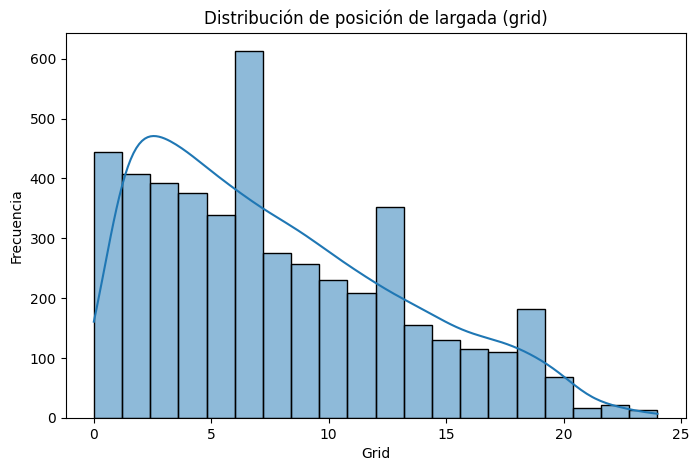

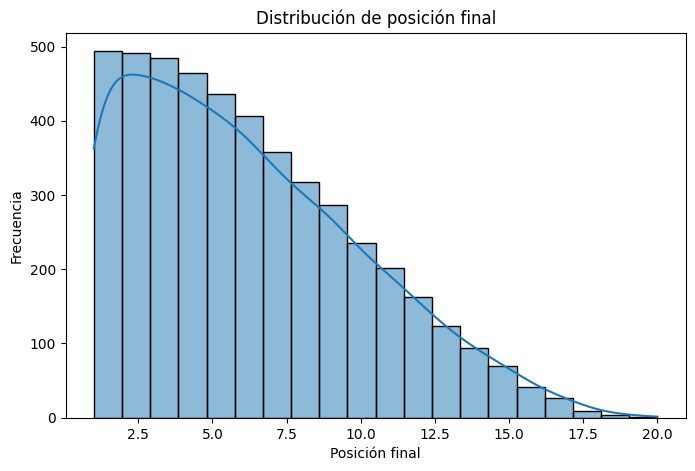

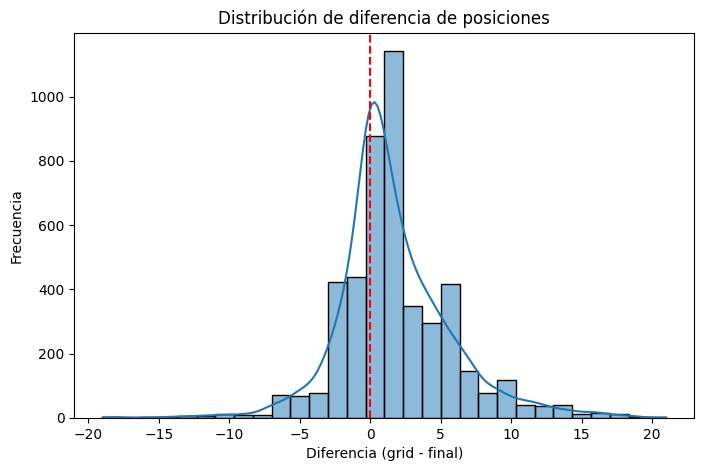

In [15]:
#analizamos variables por separado, para entender su comportamiento
import seaborn as sns
import matplotlib.pyplot as plt


#grid
plt.figure(figsize=(8,5))
sns.histplot(df_clean['grid'], bins=20, kde=True)
plt.title('Distribución de posición de largada (grid)')
plt.xlabel('Grid')
plt.ylabel('Frecuencia')
plt.show()


#positionOrder
plt.figure(figsize=(8,5))
sns.histplot(df_clean['positionOrder'], bins=20, kde=True)
plt.title('Distribución de posición final')
plt.xlabel('Posición final')
plt.ylabel('Frecuencia')
plt.show()


#diferencia_posiciones
plt.figure(figsize=(8,5))
sns.histplot(df_clean['diferencia_posiciones'], bins=30, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribución de diferencia de posiciones')
plt.xlabel('Diferencia (grid - final)')
plt.ylabel('Frecuencia')
plt.show()




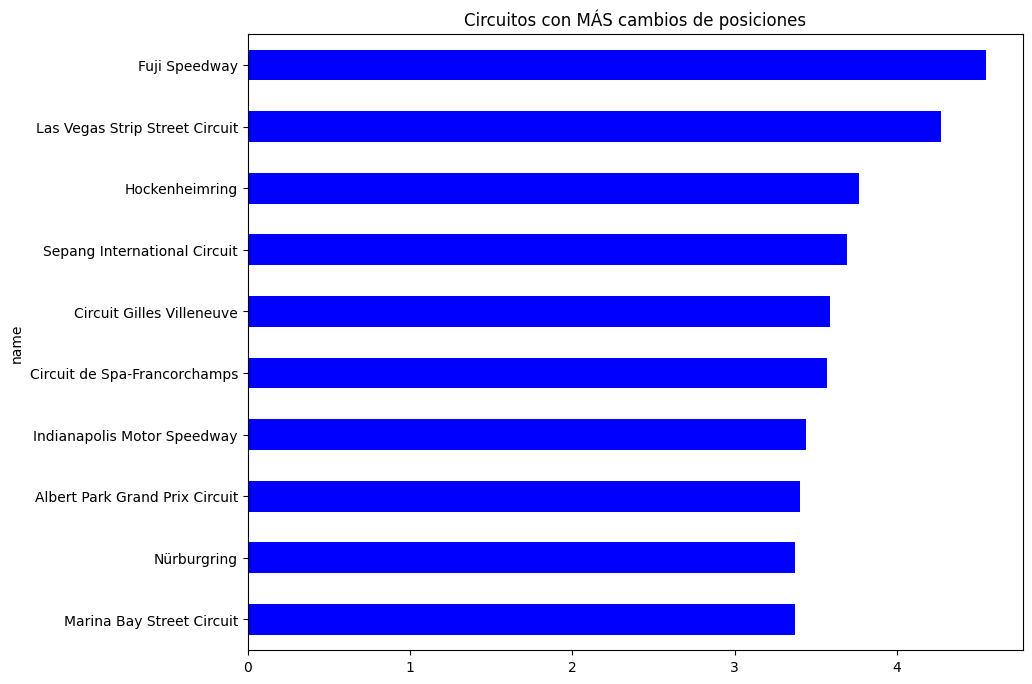

In [16]:


df_clean['movimiento_absoluto'] = df_clean['diferencia_posiciones'].abs()
movimiento_circuito = df_clean.groupby('name')['movimiento_absoluto'].mean().sort_values()


plt.figure(figsize=(10,8))
movimiento_circuito.tail(10).plot(kind='barh', color='blue')
plt.title('Circuitos con MÁS cambios de posiciones')
plt.show()




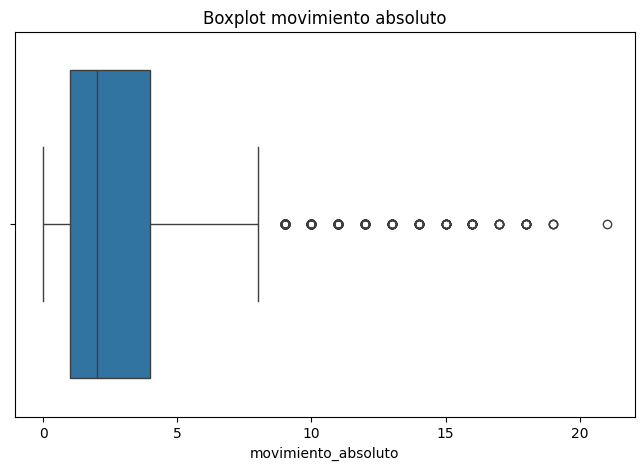

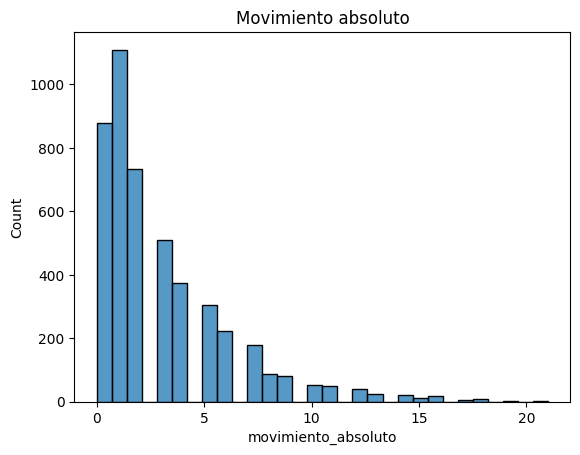

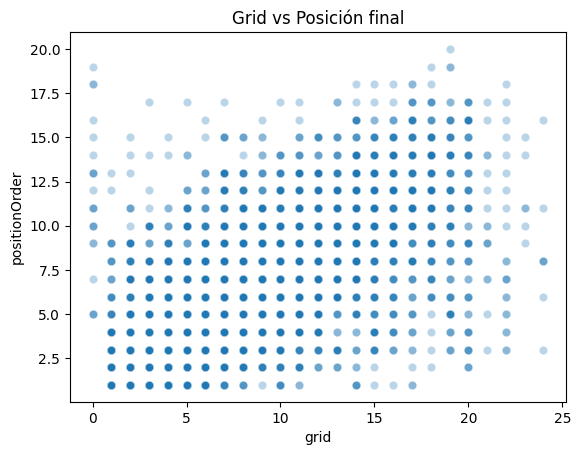

In [17]:
#Boxplots
plt.figure(figsize=(8,5))
sns.boxplot(x=df_clean['movimiento_absoluto'])
plt.title('Boxplot movimiento absoluto')
plt.show()




sns.histplot(df_clean['movimiento_absoluto'], bins=30)
plt.title('Movimiento absoluto')
plt.show()



sns.scatterplot(
   x=df_clean['grid'],
   y=df_clean['positionOrder'],
   alpha=0.3
)
plt.title('Grid vs Posición final')
plt.show()



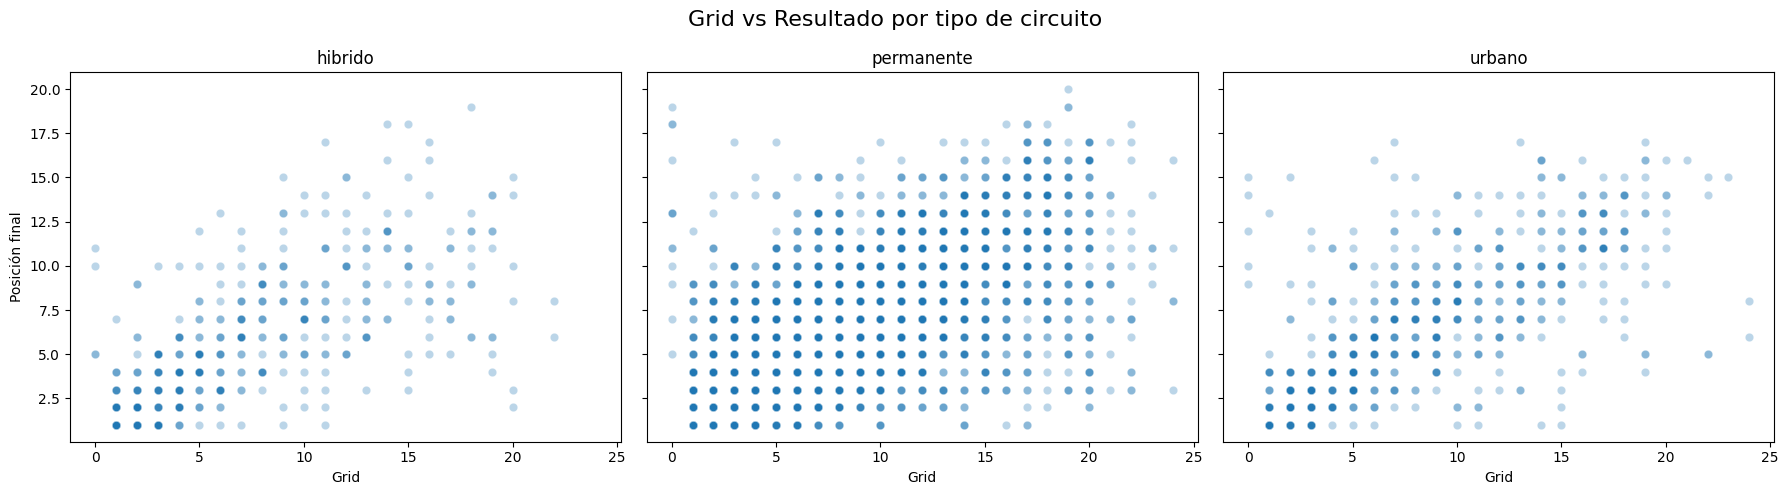

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt


tipos = df_clean['tipo_circuito'].unique()


fig, axes = plt.subplots(1, len(tipos), figsize=(18,5), sharex=True, sharey=True)


for i, tipo in enumerate(tipos):
  
   df_tipo = df_clean[df_clean['tipo_circuito'] == tipo]
  
   sns.scatterplot(
       data=df_tipo,
       x='grid',
       y='positionOrder',
       alpha=0.3,
       ax=axes[i]
   )
  
   axes[i].set_title(f'{tipo}')
   axes[i].set_xlabel('Grid')
   axes[i].set_ylabel('Posición final')


plt.suptitle('Grid vs Resultado por tipo de circuito', fontsize=16)
plt.tight_layout()
plt.show()



In [20]:
correlacion_tipo = df_clean.groupby('tipo_circuito').apply(
   lambda x: x['grid'].corr(x['positionOrder'])
)

correlacion_tipo



/var/folders/tj/1xmmj86s3q5_xbwh_9jtkz0w0000gn/T/ipykernel_85985/3890483923.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlacion_tipo = df_clean.groupby('tipo_circuito').apply(


tipo_circuito
hibrido       0.647289
permanente    0.663520
urbano        0.682884
dtype: float64

In [22]:
ranking = df_clean.groupby('name')['movimiento_absoluto'].mean().sort_values()
ranking.head(10)  # menos movimiento


name
Autódromo do Estoril                  1.545455
Okayama International Circuit         1.600000
Circuit de Nevers Magny-Cours         1.677419
Autódromo Internacional do Algarve    1.866667
Autódromo Hermanos Rodríguez          2.013514
Circuit de Barcelona-Catalunya        2.043956
Circuit Paul Ricard                   2.190476
Buddh International Circuit           2.393939
Yas Marina Circuit                    2.407609
Circuit de Monaco                     2.548223
Name: movimiento_absoluto, dtype: float64

In [23]:
ranking.tail(10)  # más movimiento


name
Marina Bay Street Circuit         3.370166
Nürburgring                       3.372549
Albert Park Grand Prix Circuit    3.401869
Indianapolis Motor Speedway       3.437500
Circuit de Spa-Francorchamps      3.570423
Circuit Gilles Villeneuve         3.589189
Sepang International Circuit      3.690141
Hockenheimring                    3.762590
Las Vegas Strip Street Circuit    4.272727
Fuji Speedway                     4.545455
Name: movimiento_absoluto, dtype: float64